# Test lc_wrapper Extension

This notebook tests that the lc_wrapper is properly installed and enabled.
- Verify that log_history metadata is recorded

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_api_url = "http://localhost:8888/api"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpn_6fjnwg


In [4]:
import importlib
import re

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.notebook7
importlib.reload(scripts.notebook7)

from scripts.playwright import *
from scripts.notebook7 import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251204-164302',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpxvmb7qxa')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1764834182.432278 seconds


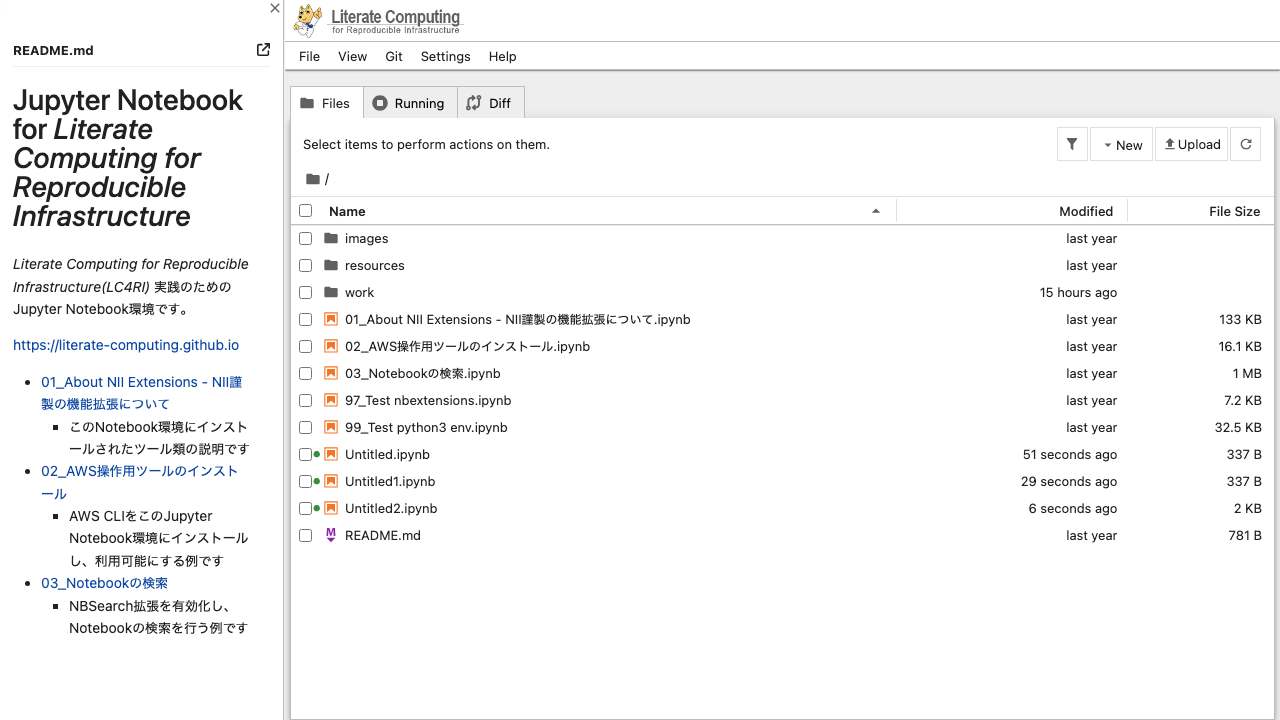

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Create a new notebook

Start epoch: 1764834184.817483 seconds


✓ New notebook created


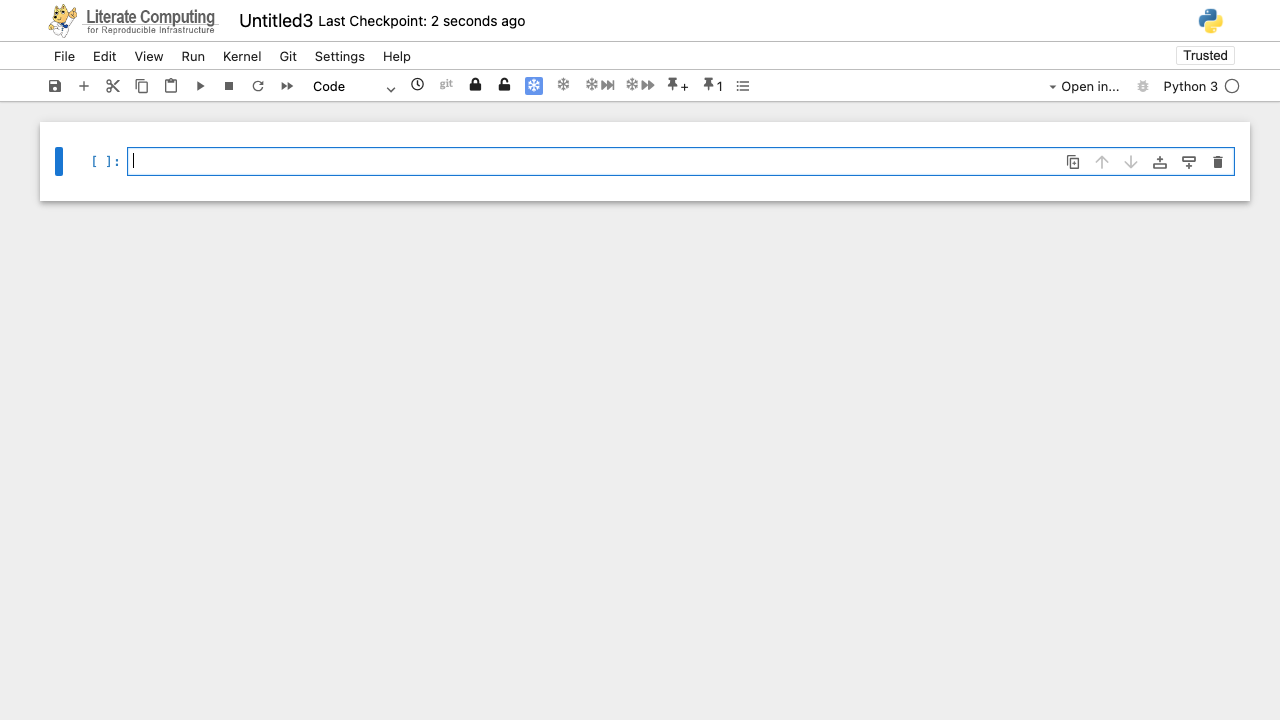

In [6]:
async def _step_create_notebook(page):
    # Create a new notebook using the notebook7 helper
    new_page = await create_new_notebook(page, kernel="Python 3", timeout=transition_timeout)
    print("✓ New notebook created")
    return new_page

await run_pw(_step_create_notebook)

## Execute a cell to trigger lc_wrapper

Start epoch: 1764834187.6091251 seconds


✓ Cell executed


✓ Notebook saved


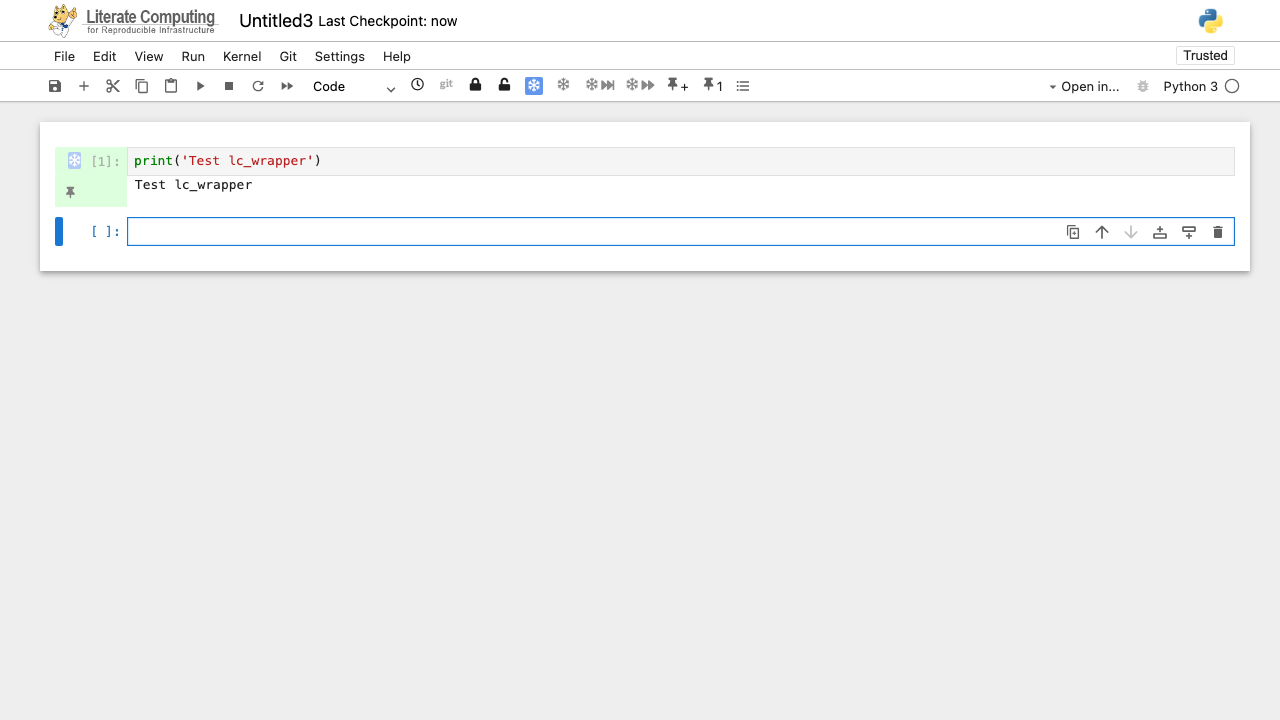

In [7]:
async def _step_execute_cell(page):
    # Create and execute a cell
    await set_cell(page, 0, "code", "print('Test lc_wrapper')", timeout=transition_timeout)
    await run_cell(page, 0, True, timeout=transition_timeout)
    print("✓ Cell executed")
    
    # Save the notebook (Ctrl+S)
    await page.keyboard.press('ControlOrMeta+S')
    await page.wait_for_timeout(1000)
    print("✓ Notebook saved")

await run_pw(_step_execute_cell)

## Verify that log_history metadata is recorded

Start epoch: 1764834192.038805 seconds
Notebook path: Untitled3.ipynb
✓ API response status: 200
Log path recorded: /home/jovyan/.log/20251204/20251204-074310-0819.log
✓ First cell 'log_history' is a valid.


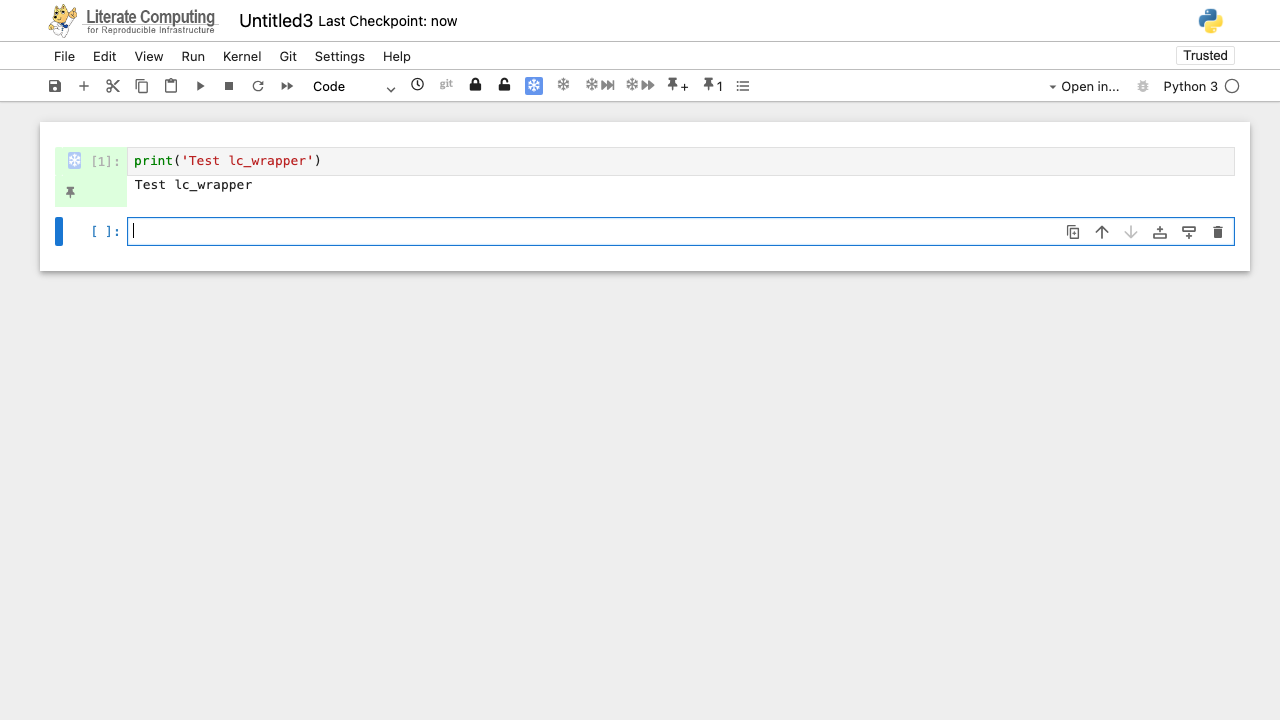

In [8]:
async def _step_verify_meta_data(page):
    # Get the notebook path from the URL
    url = page.url
    match = re.search(r'/notebooks/(.+\.ipynb)', url)
    if not match:
        raise Exception(f"Could not extract notebook path from URL: {url}")
    
    notebook_path = match.group(1)
    print(f"Notebook path: {notebook_path}")
    
    # Fetch notebook content via Jupyter API
    api_url = f"{jupyter_api_url}/contents/{notebook_path}?token={jupyter_token}"
    response = await page.request.get(api_url)
    print(f"✓ API response status: {response.status}")
    
    notebook_data = await response.json()
    
    # Check cell meme
    cells = notebook_data['content']['cells']
    assert len(cells) > 0, "No cells in notebook"
    
    first_cell = cells[0]
    assert 'metadata' in first_cell, "No metadata in first cell"
    assert 'lc_wrapper' in first_cell['metadata'], "No lc_wrapper in first cell metadata"
    
    lc_wrapper_meta_data = first_cell['metadata']['lc_wrapper']
    assert 'log_history' in lc_wrapper_meta_data, "No 'log_history' in lc_wrapper metadata"
    assert len(lc_wrapper_meta_data['log_history']) == 1, f"Expected 1 log entry, got {len(lc_wrapper_meta_data['log_history'])}"
    
    first_log_path = lc_wrapper_meta_data['log_history'][0]
    
    print(f"Log path recorded: {first_log_path}")
    print("✓ First cell 'log_history' is a valid.")

await run_pw(_step_verify_meta_data)

## Cleanup

In [ ]:
await finish_pw_context()

In [10]:
!rm -rf {work_dir}